# **Downloading the Dataset from Kaggle**












In [1]:
import kagglehub

path = kagglehub.dataset_download("mimdim/processed-rice-varieties-of-bangladesh")

print("Path to dataset files:", path)

100%|██████████| 419M/419M [00:20<00:00, 21.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mimdim/processed-rice-varieties-of-bangladesh/versions/1


In [2]:
pip install byol-pytorch

# ***Library imports***

In [3]:
# ==========================
# BASIC UTILITIES
# ==========================
import os
import random
import time
from glob import glob

# ==========================
# NUMERICAL
# ==========================
import numpy as np
import pandas as pd

# ==========================
# IMAGE & VISUALIZATION
# ==========================
from PIL import Image
import cv2
import matplotlib.pyplot as plt

# ==========================
# PYTORCH CORE
# ==========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ==========================
# TORCHVISION MODELS + TRANSFORMS
# ==========================
import torchvision.models as models
from torchvision.models import densenet121      # ✔ DenseNet backbone
from torchvision import transforms

# ==========================
# METRICS
# ==========================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# ==========================
# DATA SPLITTING
# ==========================
from sklearn.model_selection import StratifiedKFold, train_test_split

# ==========================
# PROGRESS BAR
# ==========================
from tqdm import tqdm

# ==========================
# BYOL IMPLEMENTATION
# ==========================
from byol_pytorch import BYOL

# Pretrained DenseNet121
model = densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# BYOL backbone (remove classifier head)
backbone = model.features

# BYOL learner
learner = BYOL(
    backbone,
    image_size=224,
    hidden_layer='norm5'
)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 174MB/s]


# **Dataset setup**

In [5]:
import kagglehub
import os
import pandas as pd
from glob import glob

# ==========================
# CONFIG (Minimal for this cell's needs)
# ==========================
class CFG:
    IMG_EXTS = (".png",".jpg",".jpeg",".bmp") # Required by build_index

path = kagglehub.dataset_download("mimdim/processed-rice-varieties-of-bangladesh")

# ==========================
# 1. Class Map for PRDB
# ==========================
CLASS_MAP = {
    "Aush": 0,
    "Beroi": 1,
    "BR-28": 2,
    "BR-29": 3,
    "Chinigura": 4,
    "Ghee Bhog": 5,
    "Katari Najir": 6,
    "Katari Siddho": 7,
    "Miniket": 8,
    "Swarna": 9
}
INV_CLASS = {v: k for k, v in CLASS_MAP.items()}

# Dataset root (BYOL pretraining images)
PRDB_ROOT = os.path.join(path, "PRBD Microscopic Image of Different Processed Rice/Original_Images")

assert os.path.exists(PRDB_ROOT), " ERROR: Dataset path does NOT exist!"
print("[INFO] Using PRDB root:", PRDB_ROOT)


# ==========================
# 2. Build Image Index (BYOL pretraining version)
# ==========================
def build_index(root=PRDB_ROOT):


    rows = []

    for cls_name, lbl_id in CLASS_MAP.items():
        cls_folder = os.path.join(root, cls_name)

        # Skip missing folders
        if not os.path.isdir(cls_folder):
            print(f"[WARN] Missing folder for class: {cls_name}")
            continue

        # Loop over all images inside the class folder
        for img_path in glob(os.path.join(cls_folder, "*")):

            # Check valid image extension
            if not img_path.lower().endswith(CFG.IMG_EXTS):
                continue

            # Row for dataframe (label used later in fine-tuning)
            rows.append({
                "image": img_path,
                "label": lbl_id,
                "cls": cls_name
            })

    df = pd.DataFrame(rows)
    print("\n Counts per class:")
    print(df["cls"].value_counts())

    print(f"\n[INFO] Total images found: {len(df)}")
    return df


# Build the index (mapping) for BYOL pretraining
df_all = build_index(PRDB_ROOT)

Using Colab cache for faster access to the 'processed-rice-varieties-of-bangladesh' dataset.
[INFO] Using PRDB root: /kaggle/input/processed-rice-varieties-of-bangladesh/PRBD Microscopic Image of Different Processed Rice/Original_Images

 Counts per class:
cls
Aush             200
Beroi            200
BR-28            200
BR-29            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64

[INFO] Total images found: 2000


# **Split setup**

In [7]:
# ==========================
# CONFIG (Minimal for this cell's needs)
# ==========================
class CFG:
    OUT_DIR = "/kaggle/working/byol_output"
    SEED = 42


from sklearn.model_selection import train_test_split
import shutil

# Base split dirs
base_split_dir = os.path.join(CFG.OUT_DIR, "split_data")
train_dir = os.path.join(base_split_dir, "train")
val_dir   = os.path.join(base_split_dir, "val")
test_dir  = os.path.join(base_split_dir, "test")
for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Split images class-wise (80% train, 10% val in train, 20% test)
for cls in CLASS_MAP.keys():
    imgs = df_all[df_all['cls']==cls]['image'].tolist()
    if not imgs: continue
    train_imgs, test_imgs = train_test_split(imgs, test_size=0.2, random_state=CFG.SEED)
    train_imgs, val_imgs  = train_test_split(train_imgs, test_size=0.1, random_state=CFG.SEED)
    for folder, paths in zip([train_dir,val_dir,test_dir],[train_imgs,val_imgs,test_imgs]):
        cls_folder = os.path.join(folder, cls)
        os.makedirs(cls_folder, exist_ok=True)
        for img in paths:
            shutil.copy(img, os.path.join(cls_folder, os.path.basename(img)))
    print(f"{cls}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")

Aush: Train=144, Val=16, Test=40
Beroi: Train=144, Val=16, Test=40
BR-28: Train=144, Val=16, Test=40
BR-29: Train=144, Val=16, Test=40
Chinigura: Train=144, Val=16, Test=40
Ghee Bhog: Train=144, Val=16, Test=40
Katari Najir: Train=144, Val=16, Test=40
Katari Siddho: Train=144, Val=16, Test=40
Miniket: Train=144, Val=16, Test=40
Swarna: Train=144, Val=16, Test=40


# **Unlabeled**

In [10]:
# ==========================
# CONFIG (Minimal for this cell's needs)
# ==========================
class CFG:
    IMG_EXTS = (".png",".jpg",".jpeg",".bmp") # Required by this cell

rows = []

for cls in os.listdir(PRDB_ROOT):
    folder = os.path.join(PRDB_ROOT, cls)
    if not os.path.isdir(folder):
        continue
    for img_path in glob(os.path.join(folder, "*")):
        if img_path.lower().endswith(CFG.IMG_EXTS):
            rows.append({"image": img_path})

df_unlabeled = pd.DataFrame(rows)
print("Total images for BYOL Unlabeled:",len(df_unlabeled))

Total images for BYOL Unlabeled: 2000


# **Config setup**

In [12]:
# ==========================
# IMPORTS & CONFIG
# ==========================
import os, copy, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

# ==========================
# CONFIG (Minimal for this cell's needs)
# ==========================
class CFG:
    OUT_DIR = "/kaggle/working/byol_output"


train_dir = "/content/train"  # set your dataset path
SAVE_DIR = CFG.OUT_DIR # Changed to use CFG.OUT_DIR for consistency
os.makedirs(SAVE_DIR, exist_ok=True)

# **Device config**

In [13]:
# ==========================
# DEVICE (CUDA ONLY, NO AMP)
# ==========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


# **BYOL transforms**

In [15]:
# ==========================
# CONFIG (Minimal for this cell's needs)
# ==========================
class CFG:
    IMG_SIZE = 128 # Default size, will be overwritten by comprehensive CFG later


# ==========================
# BYOL TRANSFORMS
# ==========================
class CustomBYOLTransform:
    def __init__(self, size=CFG.IMG_SIZE):
        normalize = transforms.Normalize([0.485, 0.456, 0.406],
                                         [0.229, 0.224, 0.225])
        base = transforms.Compose([
            transforms.RandomResizedCrop(size=size, scale=(0.2,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4,0.4,0.4,0.1),
            transforms.ToTensor(),
            normalize
        ])
        self.t1 = base
        self.t2 = base

    def __call__(self, img):
        return self.t1(img), self.t2(img)

# **Dataset setup (BYOL)**

In [16]:
# ==========================
# BYOL DATASET (Two Views)
# ==========================
class BYOLDataset(Dataset):
    def __init__(self, df, img_size=CFG.IMG_SIZE):
        self.df = df.reset_index(drop=True)
        self.transform = CustomBYOLTransform(size=img_size)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image"]
        img = Image.open(img_path).convert("RGB")
        return self.transform(img)  # returns (view1, view2)

    def __len__(self):
        return len(self.df)


# **BYOL DataLoader**

In [20]:
# ==========================
# CONFIG (Minimal for this cell's needs)
# ==========================
class CFG:
    SSL_BATCH = 16
    NUM_WORKERS = 2


# ==========================
# DATA LOADER
# ==========================
byol_loader = DataLoader(
    BYOLDataset(df_unlabeled),
    batch_size=CFG.SSL_BATCH,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

print(f"BYOL DataLoader ready with {len(byol_loader)} batches")

BYOL DataLoader ready with 125 batches


# **BYOL encoder**

In [21]:
# ==========================
# DENSENET121 ENCODER
# ==========================
class BYOLDenseNet121(nn.Module):
    def __init__(self):
        super().__init__()
        net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.encoder = net.features
        self.encoder_norm = nn.ReLU(inplace=True) # Added for consistency and standard practice
        self.feature_dim = 1024

    def forward(self, x):
        x = self.encoder(x)
        x = self.encoder_norm(x) # Apply ReLU
        x = F.adaptive_avg_pool2d(x, (1,1))
        return x.flatten(1)

# **BYOL network**

In [22]:
# ==========================
# MLP HEADS + BYOL MODEL
# ==========================
class MLPHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)


class BYOL(nn.Module):
    def __init__(self, encoder, proj_dim, hidden_dim):
        super().__init__()
        # Online networks
        self.online_encoder = encoder
        self.online_projector = MLPHead(encoder.feature_dim, hidden_dim, proj_dim)
        self.online_predictor = MLPHead(proj_dim, hidden_dim, proj_dim)

        # Target networks (EMA)
        self.target_encoder = copy.deepcopy(self.online_encoder)
        self.target_projector = copy.deepcopy(self.online_projector)
        for p in self.target_encoder.parameters(): p.requires_grad=False
        for p in self.target_projector.parameters(): p.requires_grad=False

    def forward(self, x1, x2):
        z1 = self.online_projector(self.online_encoder(x1))
        p1 = self.online_predictor(z1)
        z2 = self.online_projector(self.online_encoder(x2))
        p2 = self.online_predictor(z2)

        with torch.no_grad():
            t1 = self.target_projector(self.target_encoder(x1))
            t2 = self.target_projector(self.target_encoder(x2))

        return p1, p2, t1, t2

    def update_target(self, m):
        for op, tp in zip(self.online_encoder.parameters(), self.target_encoder.parameters()):
            tp.data = tp.data * m + op.data * (1 - m)
        for op, tp in zip(self.online_projector.parameters(), self.target_projector.parameters()):
            tp.data = tp.data * m + op.data * (1 - m)


# **BYOL loss**

In [23]:
# ==========================
# LOSS + SCHEDULERS
# ==========================
def byol_loss(p, z):
    p = F.normalize(p, dim=-1)
    z = F.normalize(z, dim=-1)
    return 2 - 2 * (p * z).sum(dim=-1).mean()

def cosine_lr(base, epoch, total):
    return base * 0.5 * (1 + math.cos(math.pi * epoch / total))

def cosine_momentum(base, epoch, total):
    return 1 - (1-base) * (math.cos(math.pi * epoch / total) + 1) / 2


# **Pretrain loop**

In [27]:
# ==========================
# CONFIG
# ==========================
class CFG:
    SSL_EPOCHS = 100
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-6
    PROJ_HIDDEN_DIM = 1024
    PROJ_OUT_DIM = 256
    BASE_MOMENTUM = 0.996


# ==========================
# BYOL MODEL & OPTIMIZER SETUP
# ==========================
encoder_ssl = BYOLDenseNet121().to(DEVICE)
model = BYOL(
    encoder_ssl,
    proj_dim=CFG.PROJ_OUT_DIM,
    hidden_dim=CFG.PROJ_HIDDEN_DIM
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG.SSL_LR,
    weight_decay=CFG.SSL_WEIGHT_DECAY
)

print("BYOL model and optimizer initialized.")

# ==========================
# TRAINING LOOP
# ==========================
pretrain_losses = []

for epoch in range(1, CFG.SSL_EPOCHS + 1): # Changed CFG.EPOCHS_PRETRAIN to CFG.SSL_EPOCHS
    model.train()
    total_loss = 0

    lr = cosine_lr(CFG.SSL_LR, epoch, CFG.SSL_EPOCHS) # Changed CFG.LEARNING_RATE to CFG.SSL_LR, CFG.EPOCHS_PRETRAIN to CFG.SSL_EPOCHS
    for g in optimizer.param_groups:
        g["lr"] = lr

    m = cosine_momentum(CFG.BASE_MOMENTUM, epoch, CFG.SSL_EPOCHS) # Changed CFG.MOMENTUM_BASE to CFG.BASE_MOMENTUM, CFG.EPOCHS_PRETRAIN to CFG.SSL_EPOCHS

    for x1, x2 in byol_loader:
        x1, x2 = x1.to(DEVICE), x2.to(DEVICE)

        optimizer.zero_grad()

        p1, p2, t1, t2 = model(x1, x2)
        loss = byol_loss(p1, t2) + byol_loss(p2, t1)

        loss.backward()
        optimizer.step()

        model.update_target(m)
        total_loss += loss.item()

    avg_loss = total_loss / len(byol_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch [{epoch}/{CFG.SSL_EPOCHS}] Loss: {avg_loss:.4f}") # Changed CFG.EPOCHS_PRETRAIN to CFG.SSL_EPOCHS

# ==========================
# SAVE ONLINE ENCODER
# ==========================
torch.save(model.online_encoder.state_dict(), f"{SAVE_DIR}/byol_densenet_encoder.pth")
print("Encoder saved!")

BYOL model and optimizer initialized.
Epoch [1/100] Loss: 0.5903
Epoch [2/100] Loss: 0.1262
Epoch [3/100] Loss: 0.0697
Epoch [4/100] Loss: 0.0565
Epoch [5/100] Loss: 0.0586
Epoch [6/100] Loss: 0.0635
Epoch [7/100] Loss: 0.0720
Epoch [8/100] Loss: 0.0851
Epoch [9/100] Loss: 0.0926
Epoch [10/100] Loss: 0.0929
Epoch [11/100] Loss: 0.0953
Epoch [12/100] Loss: 0.0979
Epoch [13/100] Loss: 0.0968
Epoch [14/100] Loss: 0.0922
Epoch [15/100] Loss: 0.0955
Epoch [16/100] Loss: 0.0957
Epoch [17/100] Loss: 0.0965
Epoch [18/100] Loss: 0.0853
Epoch [19/100] Loss: 0.0842
Epoch [20/100] Loss: 0.0777
Epoch [21/100] Loss: 0.0819
Epoch [22/100] Loss: 0.0798
Epoch [23/100] Loss: 0.0854
Epoch [24/100] Loss: 0.0855
Epoch [25/100] Loss: 0.0824
Epoch [26/100] Loss: 0.0784
Epoch [27/100] Loss: 0.0799
Epoch [28/100] Loss: 0.0728
Epoch [29/100] Loss: 0.0770
Epoch [30/100] Loss: 0.0754
Epoch [31/100] Loss: 0.0750
Epoch [32/100] Loss: 0.0793
Epoch [33/100] Loss: 0.0797
Epoch [34/100] Loss: 0.0715
Epoch [35/100] Loss

# **Loss Curve**

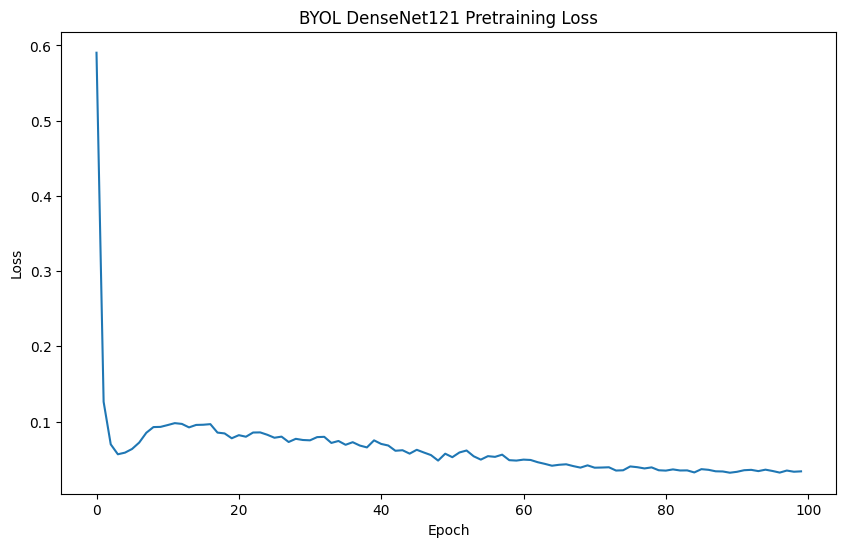

In [31]:
# ==========================
# PLOT PRETRAINING LOSS
# ==========================
plt.figure(figsize=(10,6))
plt.plot(pretrain_losses, label="BYOL Pretrain Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BYOL DenseNet121 Pretraining Loss")
plt.show()

# **Embedding analysis**
## **(T-SNE , PCA)**

Created train_df with 1440 images for evaluation.
[WARN] Pretrained encoder not found at /kaggle/working/byol_output/byol_densenet_encoder.pth. Using dummy encoder.


Extracting BYOL Features: 100%|██████████| 45/45 [00:15<00:00,  2.90it/s]


Feature shape: (1440, 1024)
Silhouette Score: 0.06


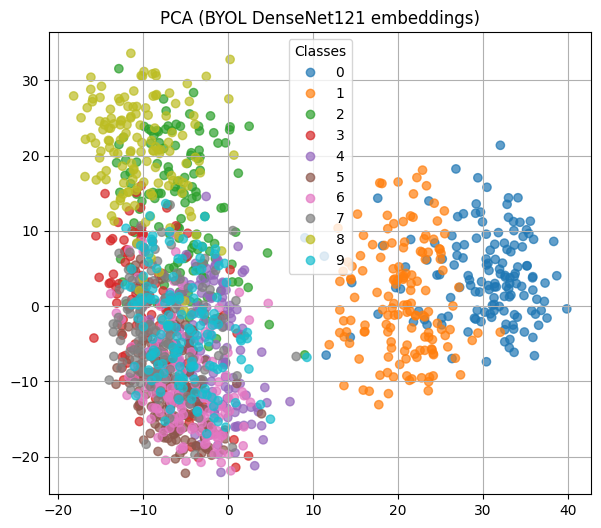

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


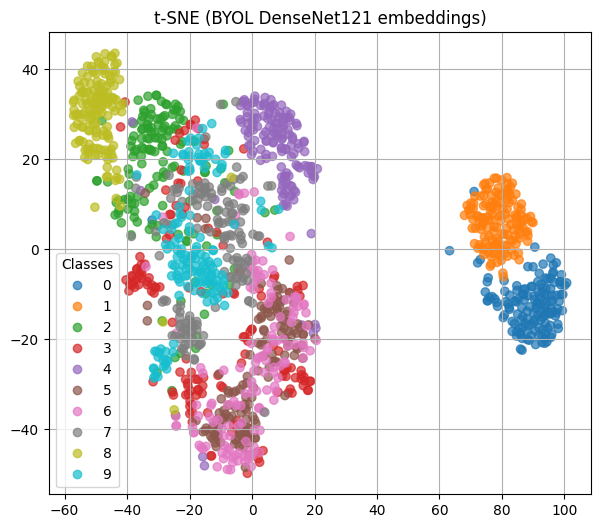

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import os
from glob import glob
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F

# ===============================
# Define CFG (ensure it always exists for this cell)
# ===============================
class CFG:
    IMG_SIZE = 128  # Used by eval_transform
    OUT_DIR = "/kaggle/working/byol_output"  # Used to derive train_dir



base_split_dir = os.path.join(CFG.OUT_DIR, "split_data")
train_dir = os.path.join(base_split_dir, "train")

if not os.path.exists(train_dir):
    print(f"[ERROR] train_dir: {train_dir} does not exist. Please run data splitting cells first to create it.")

# ===============================
# Create train_df from train_dir
# ===============================
# Re-using CLASS_MAP from earlier cells, or defining it if not present
if 'CLASS_MAP' not in globals():
    CLASS_MAP = {
        "Aush": 0, "Beroi": 1, "BR-28": 2, "BR-29": 3, "Chinigura": 4,
        "Ghee Bhog": 5, "Katari Najir": 6, "Katari Siddho": 7, "Miniket": 8, "Swarna": 9
    }
    print("[WARN] CLASS_MAP not found, using default minimal CLASS_MAP for visualization.")

train_data_rows = []
for cls_name, label_id in CLASS_MAP.items():
    cls_folder = os.path.join(train_dir, cls_name)
    if os.path.isdir(cls_folder):
        for img_path in glob(os.path.join(cls_folder, "*")):
            train_data_rows.append({"image": img_path, "label": label_id})

train_df = pd.DataFrame(train_data_rows)
print(f"Created train_df with {len(train_df)} images for evaluation.")

# ===============================
# Dataset Loader
# ===============================
class EvalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image"]).convert("RGB")
        label = self.df.loc[idx, "label"]
        if self.transform:
            img = self.transform(img)
        return img, label

# ===============================
# Transform
# ===============================
eval_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor()
])

eval_dataset = EvalDataset(train_df, transform=eval_transform)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)

class DummyEncoder(nn.Module): # Added missing class definition
    def __init__(self):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.encoder = densenet.features
        self.feature_dim = 1024 # DenseNet121 output channels
    def forward(self, x):
        x = self.encoder(x)
        x = F.adaptive_avg_pool2d(x, (1,1))
        return x.flatten(1)

# Define DEVICE here as well, for self-containment if not globally defined
if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[WARN] DEVICE not found, setting to {DEVICE} for visualization.")

# Path to the saved encoder from BYOL pretraining
ENC_PATH = os.path.join(CFG.OUT_DIR, "byol_densenet_encoder.pth")

encoder_only = DummyEncoder().to(DEVICE) # Start with dummy, try to load real
if os.path.exists(ENC_PATH):
    try:
        encoder_only.load_state_dict(torch.load(ENC_PATH, map_location=DEVICE))
        print(f"[INFO] Loaded pretrained encoder from {ENC_PATH}")
    except Exception as e:
        print(f"[WARN] Could not load pretrained encoder: {e}. Using dummy encoder.")
else:
    print(f"[WARN] Pretrained encoder not found at {ENC_PATH}. Using dummy encoder.")


encoder_only.eval()  # frozen encoder
all_feats = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(eval_loader, desc="Extracting BYOL Features"):
        imgs = imgs.to(DEVICE)
        feats = encoder_only(imgs)  # encoder output = 1024-dim BYOL embedding
        all_feats.append(feats.cpu().numpy())
        all_labels.extend(labels.numpy())

all_feats = np.concatenate(all_feats, axis=0)
all_labels = np.array(all_labels)
print("Feature shape:", all_feats.shape)

# ===============================
# Normalize embeddings
# ===============================
scaler = StandardScaler()
all_feats_norm = scaler.fit_transform(all_feats)

# ===============================
# Silhouette Score
# ===============================
sil_score = silhouette_score(all_feats_norm, all_labels)
print("Silhouette Score:", round(sil_score, 4))

# ===============================
# PCA Visualization
# ===============================
pca_feats = PCA(n_components=2).fit_transform(all_feats_norm)
plt.figure(figsize=(7,6))
scatter = plt.scatter(pca_feats[:,0], pca_feats[:,1], c=all_labels, alpha=0.7, cmap='tab10')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("PCA (BYOL DenseNet121 embeddings)")
plt.grid(True)
plt.show()

# ===============================
# t-SNE Visualization
# ===============================
tsne_feats = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=3000,
    init='pca',
    random_state=42
).fit_transform(all_feats_norm)

plt.figure(figsize=(7,6))
scatter = plt.scatter(tsne_feats[:,0], tsne_feats[:,1], c=all_labels, alpha=0.7, cmap='tab10')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE (BYOL DenseNet121 embeddings)")
plt.grid(True)
plt.show()

In [5]:
import os, shutil, random
from pathlib import Path
import kagglehub

# ==========================
# CFG (Copied for self-containment)
# ==========================
class CFG:
    DATASET_PATH = "/kaggle/input/rice-variety-bd/PRBD Microscopic Image of Different Processed Rice/Original_Images" # Not directly used for PRDB_ROOT now
    IMG_EXTS = (".png",".jpg",".jpeg",".bmp")
    IMG_SIZE = 128

    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 2

    # BYOL Pretraining Parameters
    SSL_BATCH = 16
    SSL_EPOCHS = 100
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-6
    PROJ_HIDDEN_DIM = 1024
    PROJ_OUT_DIM = 256
    PRED_HIDDEN_DIM = 512
    BASE_MOMENTUM = 0.93

    # Linear probe parameters
    LP_BATCH = 32
    LP_EPOCHS = 30
    LP_LR = 1e-3

    # Augmentation parameters (for SSLDataset)
    RANDOM_RESIZE_SCALE = (0.4, 1.0)
    ROTATION_DEG = 15
    COLOR_JITTER = (0.3, 0.3, 0.2, 0.1)
    GAUSSIAN_BLUR_KERNEL = 9
    RANDOM_ERASE_PROB = 0.05

    OUT_DIR = "/kaggle/working/byol_output"

# ==========================
# Class Map (Copied for self-containment)
# ==========================
CLASS_MAP = {
    "Aush": 0,
    "Beroi": 1,
    "BR-28": 2,
    "BR-29": 3,
    "Chinigura": 4,
    "Ghee Bhog": 5,
    "Katari Najir": 6,
    "Katari Siddho": 7,
    "Miniket": 8,
    "Swarna": 9
}

# Download dataset and define PRDB_ROOT (copied for self-containment)
path = kagglehub.dataset_download("mimdim/processed-rice-varieties-of-bangladesh")
PRDB_ROOT = os.path.join(path, "PRBD Microscopic Image of Different Processed Rice/Original_Images")

assert os.path.exists(PRDB_ROOT), " ERROR: Dataset path does NOT exist!"
print("[INFO] Using PRDB root:", PRDB_ROOT)

# -------------------------
# Paths & Config
# -------------------------
DATASET_PATH = PRDB_ROOT
OUT_DIR = CFG.OUT_DIR
SPLIT_DIR = os.path.join(OUT_DIR, "split_data")

random.seed(CFG.SEED)

# -------------------------
# Make folders
# -------------------------
for split in ["train", "val", "test"]:
    for cls in CLASS_MAP.keys(): # Use CLASS_MAP to ensure all classes are covered
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

# -------------------------
# Split images
# -------------------------
for cls in CLASS_MAP.keys(): # Iterate through defined classes
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_path): # Check if class directory exists
        print(f"[WARN] Class directory not found: {cls_path}. Skipping.")
        continue

    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(CFG.IMG_EXTS)]
    random.shuffle(imgs)

    n_total = len(imgs)
    n_train = int(n_total * 0.8)          # 80% train
    n_val = int(n_train * 0.1)            # 10% of train as validation
    n_train_final = n_train - n_val       # remaining 90% of 80% as actual train
    n_test = n_total - n_train            # 20% test

    # Copy train
    for img in imgs[:n_train_final]:
        dst = os.path.join(SPLIT_DIR, "train", cls, img)
        shutil.copy(os.path.join(cls_path, img), dst)

    # Copy val
    for img in imgs[n_train_final:n_train]:
        dst = os.path.join(SPLIT_DIR, "val", cls, img)
        shutil.copy(os.path.join(cls_path, img), dst)

    # Copy test
    for img in imgs[n_train:]:
        dst = os.path.join(SPLIT_DIR, "test", cls, img)
        shutil.copy(os.path.join(cls_path, img), dst)

print("Dataset split done: 80% train, 10% val, 20% test")

Using Colab cache for faster access to the 'processed-rice-varieties-of-bangladesh' dataset.
[INFO] Using PRDB root: /kaggle/input/processed-rice-varieties-of-bangladesh/PRBD Microscopic Image of Different Processed Rice/Original_Images
Dataset split done: 80% train, 10% val, 20% test


# **Linear probe(Frozen Encoder)**

In [6]:
# ==========================
# LINEAR PROBE (Frozen Encoder) for BYOL
# ==========================
import os, numpy as np
from tqdm import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, accuracy_score

# ==========================
# CFG
# ==========================
class CFG:
    IMG_SIZE = 128
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    LP_BATCH = 32
    LP_EPOCHS = 100
    LP_LR = 1e-3
    NUM_WORKERS = 2
    OUT_DIR = "/kaggle/working/byol_output"

CLASS_MAP = {
    "Aush":0,"Beroi":1,"BR-28":2,"BR-29":3,"Chinigura":4,
    "Ghee Bhog":5,"Katari Najir":6,"Katari Siddho":7,"Miniket":8,"Swarna":9
}
INV_CLASS = {v:k for k,v in CLASS_MAP.items()}

# ==========================
# Encoder
# ==========================
class BYOLDenseNet121(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision import models
        net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.encoder = net.features
        self.feature_dim = 1024

    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, 1)
        return x.flatten(1)

SAVE_DIR = CFG.OUT_DIR
train_dir = f"{SAVE_DIR}/split_data/train"
val_dir   = f"{SAVE_DIR}/split_data/val"
test_dir  = f"{SAVE_DIR}/split_data/test"

# ==========================
# Transforms & Datasets
# ==========================
norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
probe_tf = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    norm
])

train_ds = datasets.ImageFolder(train_dir, probe_tf)
val_ds   = datasets.ImageFolder(val_dir, probe_tf)
test_ds  = datasets.ImageFolder(test_dir, probe_tf)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=CFG.LP_BATCH, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=CFG.LP_BATCH)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=CFG.LP_BATCH)

# ==========================
# Load Encoder
# ==========================
encoder = BYOLDenseNet121()
enc_path = f"{SAVE_DIR}/byol_densenet_encoder.pth"

if os.path.exists(enc_path):
    state = torch.load(enc_path, map_location="cpu")
    new = {k.replace("encoder.",""):v for k,v in state.items() if k.startswith("encoder.")}
    encoder.encoder.load_state_dict(new, strict=True)
    print("[INFO] Loaded BYOL encoder")
else:
    print("[WARN] Encoder not found. Using random weights.")

encoder.to(CFG.DEVICE)
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

# ==========================
# Linear Classifier
# ==========================
linear = nn.Linear(encoder.feature_dim, len(CLASS_MAP)).to(CFG.DEVICE)
opt = optim.Adam(linear.parameters(), lr=CFG.LP_LR)
criterion = nn.CrossEntropyLoss()

best_val = 0
save_path = f"{SAVE_DIR}/linear_probe.pth"

# ==========================
# Training
# ==========================
@torch.no_grad()
def get_feats(x):
    return encoder(x)

for epoch in range(1, CFG.LP_EPOCHS + 1):

    linear.train()
    tot_loss = correct = total = 0

    for imgs, labels in tqdm(train_loader, desc=f"Train E{epoch}", leave=False):
        imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
        feats = get_feats(imgs)
        logits = linear(feats)

        loss = criterion(logits, labels)
        opt.zero_grad()
        loss.backward()
        opt.step()

        tot_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    train_loss = tot_loss / total
    train_acc = correct / total

    # ----- Validation -----
    linear.eval()
    val_correct = val_total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(CFG.DEVICE), labels.to(CFG.DEVICE)
            feats = get_feats(imgs)
            logits = linear(feats)

            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total += imgs.size(0)

    val_acc = val_correct / val_total

    # ---- Output (your requested format) ----
    print(f"\nEpoch {epoch} Train Loss={train_loss:.4f}  Acc={train_acc:.4f}")
    print(f"  -> Val Acc={val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(linear.state_dict(), save_path)
        print(f"  -> Best linear probe saved: {save_path}")

print(f"\n[DONE] Best val acc: {best_val:.4f}")

# ==========================
# Test Evaluation
# ==========================
linear.load_state_dict(torch.load(save_path, map_location=CFG.DEVICE))
linear.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(CFG.DEVICE)
        feats = get_feats(imgs)
        logits = linear(feats)

        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# ---- FINAL TEST OUTPUT ----
acc = accuracy_score(all_labels, all_preds)
print(f"\n[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(CLASS_MAP.keys())))


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 120MB/s]


[WARN] Encoder not found. Using random weights.



Epoch 1 Train Loss=1.4101  Acc=0.5507
  -> Val Acc=0.8187
  -> Best linear probe saved: /kaggle/working/byol_output/linear_probe.pth



Epoch 2 Train Loss=0.6973  Acc=0.8028
  -> Val Acc=0.8562
  -> Best linear probe saved: /kaggle/working/byol_output/linear_probe.pth


...


Epoch 96 Train Loss=0.0255  Acc=1.0000
  -> Val Acc=0.9313



Epoch 97 Train Loss=0.0259  Acc=0.9993
  -> Val Acc=0.9313



Epoch 98 Train Loss=0.0246  Acc=1.0000
  -> Val Acc=0.9437



Epoch 99 Train Loss=0.0235  Acc=1.0000
  -> Val Acc=0.9375



Epoch 100 Train Loss=0.0221  Acc=1.0000
  -> Val Acc=0.9375

[DONE] Best val acc: 0.9563

[TEST] Accuracy: 0.9150
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      0.93      0.96        40
        Beroi       0.80      0.88      0.83        40
        BR-28       0.89      0.97      0.93        40
        BR-29       0.95      1.00      0.98        40
    Chinigura       0.97      0.95      0.96        40
    Ghee Bhog       0.86      0.90      0.88        40
 Katari Najir       0.86      0.75      0.80        40
Katari Siddho       0.93      0.93      0.93        40
      Miniket       1.00      0.93      0.96        40
       Swarna       0.93      0.93      0.93        40

     accuracy                           0.92       400
    macro avg       0.92      0.92      0.91       400
 weighted avg       0.92      0.92      0.91       400



# **MLP PROBE (Frozen BYOL Encoder)**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
class CFG:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_SIZE = 128
    OUT_DIR = "/kaggle/working/byol_output"  # BYOL save directory
    BATCH_SIZE = 32
    NUM_CLASSES = 10  # Number of classes in PRDB
    LR = 1e-3
    EPOCHS = 200  # Linear probe epochs

device = torch.device(CFG.DEVICE)
print("Device:", device)

# -----------------------------
# FROZEN BYOL ENCODER
# -----------------------------
class EncoderOnly(nn.Module):
    def __init__(self):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.encoder = densenet.features
        self.feature_dim = 1024

    def forward(self, x):
        x = self.encoder(x)
        x = F.adaptive_avg_pool2d(x, (1,1))
        return x.flatten(1)

encoder_only = EncoderOnly().to(device)
encoder_path = os.path.join(CFG.OUT_DIR, "byol_densenet_encoder.pth")
encoder_only.load_state_dict(torch.load(encoder_path, map_location=device))
encoder_only.eval()
for p in encoder_only.parameters():
    p.requires_grad = False
print("Frozen BYOL encoder loaded!")

# -----------------------------
# LINEAR CLASSIFIER
# -----------------------------
class LinearClassifier(nn.Module):
    def __init__(self, feat_dim=1024, hidden=512, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.encoder = encoder_only  # frozen
        self.mlp = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            feats = self.encoder(x)
        return self.mlp(feats)

model = LinearClassifier().to(device)

# -----------------------------
# DATA LOADERS
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor()
])

train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)

# CLASS NAMES
CLASS_MAP = {i: c for i, c in enumerate(train_ds.classes)}
target_names = [CLASS_MAP[i] for i in range(len(CLASS_MAP))]

# -----------------------------
# TRAINING SETUP
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.mlp.parameters(), lr=CFG.LR)
best_acc = 0

for epoch in range(1, CFG.EPOCHS + 1):
    model.train()
    total, correct, running_loss = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS}")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch} Train Loss={train_loss:.4f}  Acc={train_acc:.4f}")

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            preds = out.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch} Val Acc={val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        save_path = os.path.join(CFG.OUT_DIR, "best_linear_classifier.pth")
        torch.save(model.state_dict(), save_path)
        print(f"  -> Best model saved: {save_path}")

print("Best Validation Accuracy:", best_acc)

# -----------------------------
# TEST EVALUATION
# -----------------------------
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))


Device: cuda
Frozen BYOL encoder loaded!


Epoch 1/200: 100%|██████████| 45/45 [00:16<00:00,  2.79it/s, loss=0.5004]

Epoch 1 Train Loss=0.6712  Acc=0.7451


Epoch 1 Val Acc=0.8063
  -> Best model saved: /kaggle/working/byol_output/best_linear_classifier.pth


Epoch 2/200: 100%|██████████| 45/45 [00:11<00:00,  3.90it/s, loss=0.7645]

...

Epoch 199 Train Loss=0.0616  Acc=0.9806


Epoch 199 Val Acc=0.9313


Epoch 200/200: 100%|██████████| 45/45 [00:11<00:00,  3.81it/s, loss=0.4438]

Epoch 200 Train Loss=0.0718  Acc=0.9833


Epoch 200 Val Acc=0.9375
Best Validation Accuracy: 0.95625
[TEST] Accuracy: 0.9225
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      0.97      0.99        40
        BR-28       0.92      0.82      0.87        40
        BR-29       0.95      0.93      0.94        40
        Beroi       0.98      1.00      0.99        40
    Chinigura       1.00      1.00      1.00        40
    Ghee Bhog       0.96      0.68      0.79        40
 Katari Najir       0.70      0.95      0.81        40
Katari Siddho       0.90      0.95      0.93        40
      Miniket       1.00      1.00      1.00        40
       Swarna       0.90      0.93      0.91        40

     accuracy                           0.92       400
    macro avg       0.93      0.92      0.92       400
 weighted avg       0.93      0.92      0.92       400



In [33]:
import torch
import os

SAVE_DIR = "/kaggle/working/byol_output"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save only the encoder weights (online encoder)
torch.save(model.online_encoder.state_dict(), os.path.join(SAVE_DIR, "byol_densenet_encoder.pth"))
print("BYOL encoder saved successfully!")


BYOL encoder saved successfully!


In [34]:
encoder_path = "/kaggle/working/byol_output/byol_densenet_encoder.pth"


# **SVM on BYOL embeddings**

In [ ]:
#SVM
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# ==============================
# CONFIG
# ==============================
class CFG:
    OUT_DIR = "/kaggle/working/byol_output"  # BYOL pretraining output folder
    IMG_SIZE = 128
    BATCH_SIZE = 32
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

device = torch.device(CFG.DEVICE)

# ==============================
# ENCODER (DenseNet121) FOR BYOL
# ==============================
class EncoderOnly(nn.Module):
    def __init__(self):
        super().__init__()
        net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.encoder = net.features
        self.feature_dim = 1024

    def forward(self, x):
        x = self.encoder(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1,1))
        return x.flatten(1)

# Load BYOL pretrained encoder
encoder_path = os.path.join(CFG.OUT_DIR, "byol_densenet_encoder.pth")
encoder_only = EncoderOnly().to(device)
if os.path.exists(encoder_path):
    encoder_only.load_state_dict(torch.load(encoder_path, map_location=device))
    print("BYOL encoder loaded successfully!")
else:
    raise FileNotFoundError(f"No encoder checkpoint found at {encoder_path}")

encoder_only.eval()
for p in encoder_only.parameters():
    p.requires_grad = False  # freeze

# ==============================
# DATASET & DATALOADER
# ==============================
svm_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor()
])

train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=svm_transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"),   transform=svm_transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"),  transform=svm_transform)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)

# ==============================
# FEATURE EXTRACTION
# ==============================
def extract_features(loader, model, device):
    model.eval()
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = model(imgs)
            feats_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    feats_all = np.concatenate(feats_list, axis=0)
    labels_all = np.concatenate(labels_list, axis=0)
    return feats_all, labels_all

X_train, y_train = extract_features(train_loader, encoder_only, device)
X_val, y_val     = extract_features(val_loader, encoder_only, device)
X_test, y_test   = extract_features(test_loader, encoder_only, device)

print("Feature shapes:", X_train.shape, X_val.shape, X_test.shape)

# ==============================
# SVM CLASSIFIER
# ==============================
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

val_pred = svm_clf.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print(f"[VAL] Accuracy: {val_acc:.4f}")

test_pred = svm_clf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"[TEST] Accuracy: {test_acc:.4f}")

# ==============================
# CLASSIFICATION REPORT
# ==============================
CLASS_MAP = {cls: i for i, cls in enumerate(train_ds.classes)}
print("Classification Report:")
print(classification_report(y_test, test_pred, target_names=list(CLASS_MAP.keys())))


BYOL encoder loaded successfully!
Feature shapes: (1440, 1024) (160, 1024) (400, 1024)
[VAL] Accuracy: 0.8875
[TEST] Accuracy: 0.9050
Classification Report:
               precision    recall  f1-score   support

         Aush       0.97      0.97      0.97        40
        BR-28       0.87      0.85      0.86        40
        BR-29       0.88      0.93      0.90        40
        Beroi       0.97      0.97      0.97        40
    Chinigura       0.95      1.00      0.98        40
    Ghee Bhog       0.86      0.78      0.82        40
 Katari Najir       0.74      0.72      0.73        40
Katari Siddho       0.90      0.90      0.90        40
      Miniket       0.98      1.00      0.99        40
       Swarna       0.90      0.93      0.91        40

     accuracy                           0.91       400
    macro avg       0.90      0.91      0.90       400
 weighted avg       0.90      0.91      0.90       400



# **Decision Tree**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import os

# -----------------------------
# CONFIG
# -----------------------------
class CFG:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    OUT_DIR = "/kaggle/working/byol_output"  # BYOL pretraining output
    IMG_SIZE = 128
    BATCH_SIZE = 32
    SEED = 42

device = torch.device(CFG.DEVICE)
print("Device:", device)

# -----------------------------
# LOAD FROZEN BYOL ENCODER
# -----------------------------
class EncoderOnly(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision import models
        densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.encoder = densenet.features
        self.feature_dim = 1024

    def forward(self, x):
        x = self.encoder(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1,1))
        return x.flatten(1)

encoder_only = EncoderOnly().to(device)
encoder_path = os.path.join(CFG.OUT_DIR, "byol_densenet_encoder.pth")
encoder_only.load_state_dict(torch.load(encoder_path, map_location=device))
encoder_only.eval()
for p in encoder_only.parameters():
    p.requires_grad = False
print("Frozen BYOL encoder loaded!")

# -----------------------------
# TRANSFORMS & DATASETS
# -----------------------------
transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor()
])

train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

# -----------------------------
# FEATURE EXTRACTION FUNCTION
# -----------------------------
def extract_features(dataset, encoder, device):
    loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
    all_feats, all_labels = [], []
    encoder.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = encoder(imgs)
            all_feats.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_feats), np.hstack(all_labels)

print("Extracting features...")
X_train, y_train = extract_features(train_ds, encoder_only, device)
X_val, y_val     = extract_features(val_ds, encoder_only, device)
X_test, y_test   = extract_features(test_ds, encoder_only, device)

# -----------------------------
# TRAIN DECISION TREE
# -----------------------------
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

dt_clf = DecisionTreeClassifier(max_depth=None, random_state=CFG.SEED)
dt_clf.fit(X_train_full, y_train_full)

# -----------------------------
# TEST EVALUATION
# -----------------------------
y_pred = dt_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"[TEST] Accuracy: {acc:.4f}")

# CLASS_MAP: numeric -> class name
CLASS_MAP = {v: k for k, v in train_ds.class_to_idx.items()}

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=[CLASS_MAP[i] for i in range(len(CLASS_MAP))]
))


Device: cuda
Frozen BYOL encoder loaded!
Extracting features...
[TEST] Accuracy: 0.8200
Classification Report:
               precision    recall  f1-score   support

         Aush       0.97      0.97      0.97        40
        BR-28       0.71      0.85      0.77        40
        BR-29       0.79      0.75      0.77        40
        Beroi       0.97      0.93      0.95        40
    Chinigura       0.93      1.00      0.96        40
    Ghee Bhog       0.71      0.75      0.73        40
 Katari Najir       0.65      0.55      0.59        40
Katari Siddho       0.77      0.68      0.72        40
      Miniket       0.97      0.93      0.95        40
       Swarna       0.73      0.80      0.76        40

     accuracy                           0.82       400
    macro avg       0.82      0.82      0.82       400
 weighted avg       0.82      0.82      0.82       400



# **Random Forest**

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
class CFG:
    OUT_DIR = "/kaggle/working/byol_output"  # BYOL pretraining save dir
    IMG_SIZE = 128
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 32

device = torch.device(CFG.DEVICE)
print("Device:", device)

# -----------------------------
# FROZEN BYOL ENCODER
# -----------------------------
class EncoderOnly(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision import models
        densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.encoder = densenet.features
        self.feature_dim = 1024

    def forward(self, x):
        x = self.encoder(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1,1))
        return x.flatten(1)

encoder_only = EncoderOnly().to(device)

encoder_path = os.path.join(CFG.OUT_DIR, "byol_densenet_encoder.pth")
encoder_only.load_state_dict(torch.load(encoder_path, map_location=device))
encoder_only.eval()
for p in encoder_only.parameters():
    p.requires_grad = False
print("Frozen BYOL encoder loaded!")

# -----------------------------
# DATASET & TRANSFORM
# -----------------------------
eval_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=eval_transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"), transform=eval_transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"), transform=eval_transform)

# CLASS_MAP strings for report
CLASS_MAP = {v: k for k, v in train_ds.class_to_idx.items()}
target_names = [CLASS_MAP[i] for i in range(len(CLASS_MAP))]

# -----------------------------
# FEATURE EXTRACTION
# -----------------------------
def extract_features(dataset, encoder, batch_size=CFG.BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    features_list, labels_list = [], []
    encoder.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting features"):
            imgs = imgs.to(device)
            feats = encoder(imgs)
            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return features, labels

print("Extracting train features...")
X_train, y_train = extract_features(train_ds, encoder_only)
print("Extracting val features...")
X_val, y_val     = extract_features(val_ds, encoder_only)
print("Extracting test features...")
X_test, y_test   = extract_features(test_ds, encoder_only)

# -----------------------------
# RANDOM FOREST CLASSIFIER
# -----------------------------
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(np.vstack([X_train, X_val]), np.hstack([y_train, y_val]))  # combine train+val

y_pred = rf_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"[TEST] Accuracy: {acc:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Device: cuda
Frozen BYOL encoder loaded!
Extracting train features...


Extracting features: 100%|██████████| 45/45 [00:16<00:00,  2.72it/s]


Extracting val features...


Extracting features: 100%|██████████| 5/5 [00:01<00:00,  3.56it/s]


Extracting test features...


Extracting features: 100%|██████████| 13/13 [00:03<00:00,  4.03it/s]


[TEST] Accuracy: 0.9000
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      0.97      0.99        40
        BR-28       0.81      0.88      0.84        40
        BR-29       0.83      0.95      0.88        40
        Beroi       0.98      1.00      0.99        40
    Chinigura       0.93      1.00      0.96        40
    Ghee Bhog       0.90      0.88      0.89        40
 Katari Najir       0.84      0.68      0.75        40
Katari Siddho       0.88      0.90      0.89        40
      Miniket       0.97      0.93      0.95        40
       Swarna       0.87      0.82      0.85        40

     accuracy                           0.90       400
    macro avg       0.90      0.90      0.90       400
 weighted avg       0.90      0.90      0.90       400



# **Fine-Tune Model**

In [ ]:
import os, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# CONFIG
# -----------------------------
class CFG:
    OUT_DIR = "/kaggle/working/byol_output"  # BYOL pretraining save dir
    IMG_SIZE = 224
    BATCH_SIZE = 32
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_CLASSES = 10
    FT_EPOCHS = 200
    FT_LR = 1e-3
    SEED = 42

device = torch.device(CFG.DEVICE)
os.makedirs(CFG.OUT_DIR, exist_ok=True)

# -----------------------------
# Seed
# -----------------------------
def set_seed(seed=CFG.SEED):
    random.seed(seed)
    import numpy as np
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

# -----------------------------
# BYOL Encoder (DenseNet121)
# -----------------------------
class EncoderOnly(nn.Module):
    def __init__(self):
        super().__init__()
        densenet = models.densenet121(weights=None)
        self.encoder = densenet.features
        self.feature_dim = 1024
    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1,1))
        return torch.flatten(x,1)

encoder_only = EncoderOnly().to(device)
encoder_path = os.path.join(CFG.OUT_DIR, "byol_densenet_encoder.pth")
encoder_only.load_state_dict(torch.load(encoder_path, map_location=device))
encoder_only.eval()
for p in encoder_only.parameters():
    p.requires_grad = False
print("Frozen BYOL encoder loaded!")

# -----------------------------
# Fine-Tune Model (Linear Classifier)
# -----------------------------
class FineTuneModel(nn.Module):
    def __init__(self, encoder, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(1024, num_classes)
    def forward(self, x):
        with torch.no_grad():  # encoder frozen
            feats = self.encoder(x)
        out = self.classifier(feats)
        return out

ft_model = FineTuneModel(encoder_only).to(device)

# -----------------------------
# DATA LOADERS
# -----------------------------
transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor()
])

train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=2)

# -----------------------------
# TRAINING SETUP
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ft_model.classifier.parameters(), lr=CFG.FT_LR)

best_val_acc = 0.0
for epoch in range(1, CFG.FT_EPOCHS+1):
    ft_model.train()
    total, correct, running_loss = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"FT Epoch {epoch}/{CFG.FT_EPOCHS}")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = ft_model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch} Train Loss={train_loss:.4f} Acc={train_acc:.4f}")

    # Validation
    ft_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = ft_model(imgs)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch} Val Acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_path = os.path.join(CFG.OUT_DIR, "fine_tuned_byol_classifier.pth")
        torch.save(ft_model.state_dict(), save_path)
        print(f"  -> New Best Fine-Tuned Model Saved: {save_path}")

print("Best Validation Accuracy:", best_val_acc)

# -----------------------------
# TEST EVALUATION
# -----------------------------
ft_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = ft_model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=[c for c in train_ds.classes]))


Frozen BYOL encoder loaded!


FT Epoch 1/200: 100%|██████████| 45/45 [00:13<00:00,  3.28it/s, loss=0.6229]

Epoch 1 Train Loss=0.8786 Acc=0.7292


Epoch 1 Val Acc=0.7937
  -> New Best Fine-Tuned Model Saved: /kaggle/working/byol_output/fine_tuned_byol_classifier.pth


FT Epoch 2/200: 100%|██████████| 45/45 [00:13<00:00,  3.35it/s, loss=0.3225]

...

FT Epoch 199/200: 100%|██████████| 45/45 [00:13<00:00,  3.32it/s, loss=0.0393]

Epoch 199 Train Loss=0.0999 Acc=0.9535


Epoch 199 Val Acc=0.9375


FT Epoch 200/200: 100%|██████████| 45/45 [00:13<00:00,  3.33it/s, loss=0.0736]


Epoch 200 Train Loss=0.0989 Acc=0.9618
Epoch 200 Val Acc=0.9375
Best Validation Accuracy: 0.95625
[TEST] Accuracy: 0.9625
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       0.92      0.88      0.90        40
        BR-29       0.98      1.00      0.99        40
        Beroi       1.00      1.00      1.00        40
    Chinigura       1.00      1.00      1.00        40
    Ghee Bhog       0.97      0.88      0.92        40
 Katari Najir       0.88      0.95      0.92        40
Katari Siddho       0.97      0.93      0.95        40
      Miniket       1.00      1.00      1.00        40
       Swarna       0.91      1.00      0.95        40

     accuracy                           0.96       400
    macro avg       0.96      0.96      0.96       400
 weighted avg       0.96      0.96      0.96       400

